<a href="https://colab.research.google.com/github/ReethuS10/Neurodivergence/blob/main/GEN_AI_Bootcamp_Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install transformers==4.41.2 torch torchvision pillow matplotlib pandas tqdm gradio accelerate sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 134.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.3/32.3 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 130.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/GEN_AI_Bootcamp/archive (1).zip"
extract_path = "/content/fashion_dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

print("Dataset Ready!")
print(os.listdir(extract_path))

Dataset Ready!
['myntradataset', 'styles.csv', 'images']


In [4]:
import os
import random
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from transformers import CLIPProcessor, CLIPModel

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

model = model.to(device)
model.eval()

print("Device:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Device: cuda


In [6]:
IMAGE_FOLDER = "/content/fashion_dataset/images"

image_files = [
    os.path.join(IMAGE_FOLDER, f)
    for f in os.listdir(IMAGE_FOLDER)
    if f.endswith((".jpg", ".jpeg", ".png"))
]

print("Total Images:", len(image_files))

random.seed(42)
image_files = random.sample(image_files, 500)

print("Using:", len(image_files))

Total Images: 44441
Using: 500


In [7]:
from torch.utils.data import DataLoader
from torchvision import transforms

BATCH_SIZE = 32

images = []
valid_paths = []

for path in image_files:
    try:
        img = Image.open(path).convert("RGB")
        images.append(img)
        valid_paths.append(path)
    except:
        pass

image_files = valid_paths

image_embeddings = []

with torch.no_grad():

    for i in tqdm(range(0, len(images), BATCH_SIZE)):

        batch = images[i:i+BATCH_SIZE]

        inputs = processor(
            images=batch,
            return_tensors="pt",
            padding=True
        ).to(device)

        features = model.get_image_features(
            pixel_values=inputs["pixel_values"]
        )

        features = F.normalize(features, p=2, dim=1)

        image_embeddings.append(features.cpu())

image_embeddings = torch.cat(image_embeddings, dim=0)

print("✅ Embeddings Ready")
print(image_embeddings.shape)

100%|██████████| 16/16 [00:06<00:00,  2.59it/s]

✅ Embeddings Ready
torch.Size([500, 512])


In [8]:
text = "blue casual shirt"

inputs = processor(
    text=[text],
    return_tensors="pt",
    padding=True
).to(device)

with torch.no_grad():
    text_features = model.get_text_features(**inputs)

text_features = F.normalize(text_features, p=2, dim=1)

print(text_features.shape)

torch.Size([1, 512])


In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import torch

def search_products(query, top_k=5):

    inputs = processor(
        text=[query],
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        text_features = model.get_text_features(**inputs)

    text_features = F.normalize(text_features, p=2, dim=1)

    similarity = torch.matmul(
        image_embeddings,
        text_features.cpu().T
    ).squeeze()

    top_indices = similarity.topk(top_k).indices.tolist()

    plt.figure(figsize=(15,5))

    for i, idx in enumerate(top_indices):

        img = Image.open(image_files[idx])

        plt.subplot(1, top_k, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Rank {i+1}")

    plt.suptitle(f"Search: {query}", fontsize=16)
    plt.show()

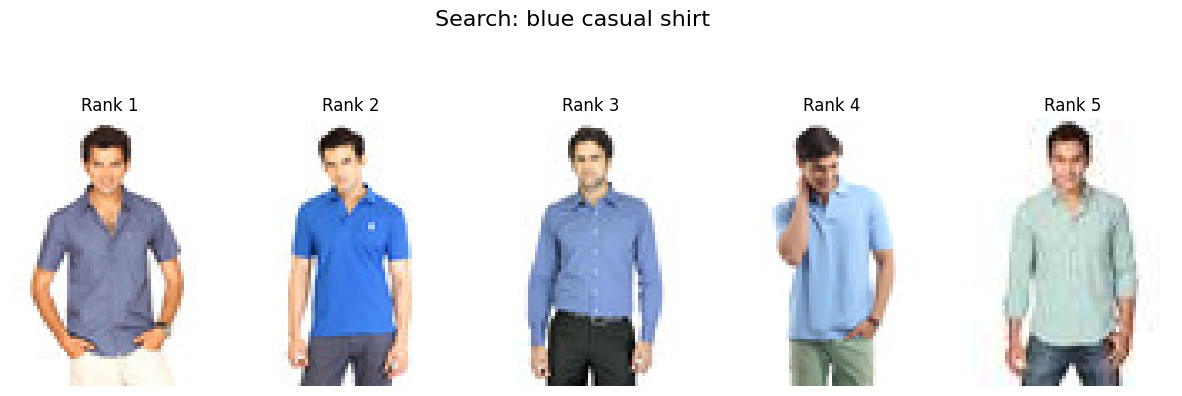

In [10]:
search_products("blue casual shirt")

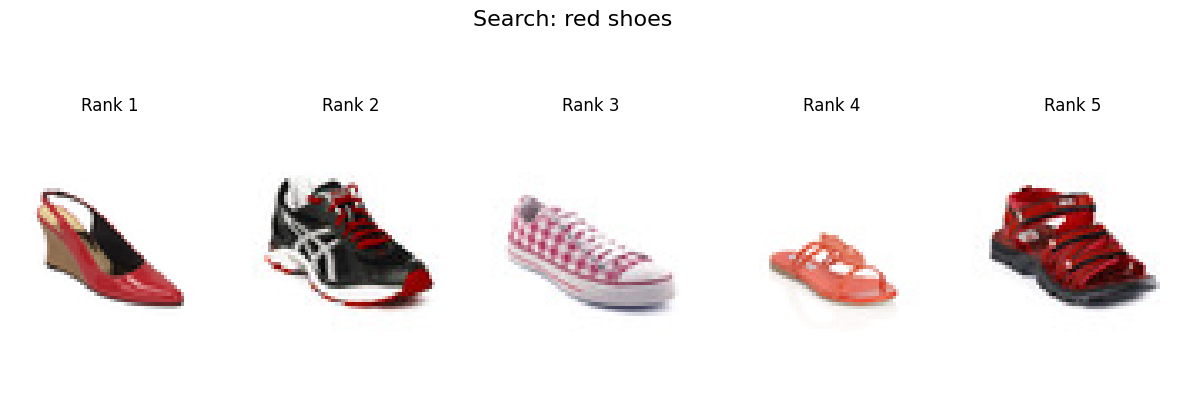

In [11]:
search_products("red shoes")

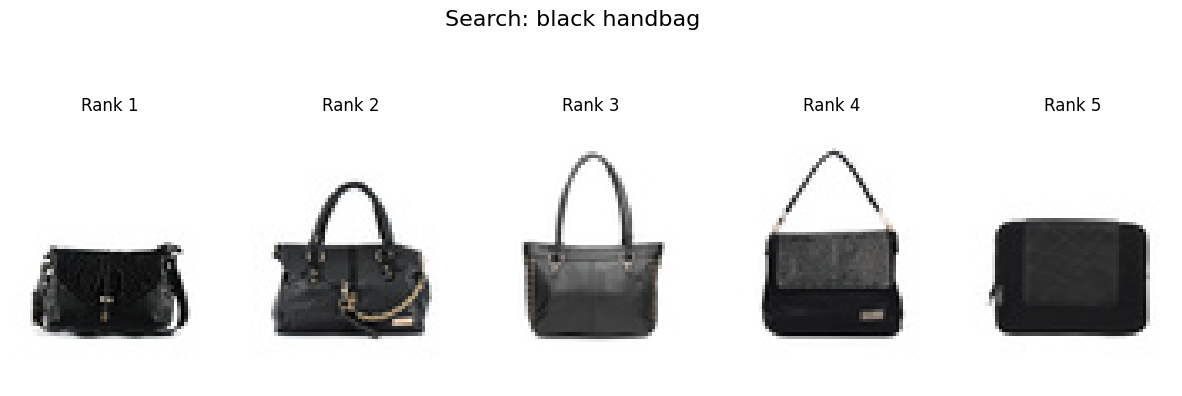

In [12]:
search_products("black handbag")

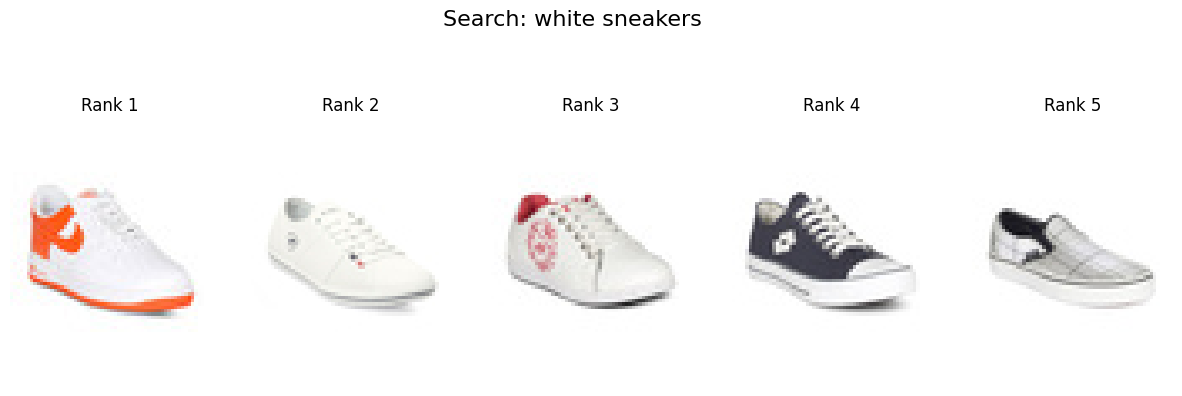

In [13]:
search_products("white sneakers")

In [14]:
recommendations = {

    "running shoes": [
        "Sports Socks",
        "Fitness Watch",
        "Water Bottle",
        "Sports Cap",
        "Track Pants"
    ],

    "shirt": [
        "Jeans",
        "Leather Belt",
        "Sneakers",
        "Watch",
        "Sunglasses"
    ],

    "tshirt": [
        "Jeans",
        "Sneakers",
        "Cap",
        "Backpack",
        "Sports Watch"
    ],

    "handbag": [
        "Wallet",
        "Sunglasses",
        "Scarf",
        "Heels",
        "Perfume"
    ],

    "dress": [
        "High Heels",
        "Handbag",
        "Necklace",
        "Bracelet",
        "Perfume"
    ],

    "sneakers": [
        "Sports Socks",
        "Backpack",
        "Cap",
        "Fitness Band",
        "Water Bottle"
    ]

}

In [15]:
def recommend_products(product):

    product = product.lower()

    if product in recommendations:

        print("="*50)
        print("Input Product :", product.title())
        print("="*50)

        print("\nRecommended Products:\n")

        for item in recommendations[product]:
            print("•", item)

    else:

        print("No recommendations available.")

In [16]:
recommend_products("running shoes")

Input Product : Running Shoes

Recommended Products:

• Sports Socks
• Fitness Watch
• Water Bottle
• Sports Cap
• Track Pants


In [17]:
recommend_products("shirt")

Input Product : Shirt

Recommended Products:

• Jeans
• Leather Belt
• Sneakers
• Watch
• Sunglasses


In [18]:
recommend_products("handbag")

Input Product : Handbag

Recommended Products:

• Wallet
• Sunglasses
• Scarf
• Heels
• Perfume


In [19]:
import gradio as gr
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F

def reverse_search(query):

    inputs = processor(
        text=[query],
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        text_features = model.get_text_features(**inputs)

    text_features = F.normalize(text_features, p=2, dim=1)

    similarity = torch.matmul(
        image_embeddings,
        text_features.cpu().T
    ).squeeze()

    top_indices = similarity.topk(5).indices.tolist()

    images = []

    for idx in top_indices:
        images.append(Image.open(image_files[idx]))

    return images


def smart_recommend(product):

    product = product.lower()

    if product in recommendations:
        return "\n".join(recommendations[product])

    return "No recommendation available."


with gr.Blocks(title="AI Product Intelligence System") as demo:

    gr.Markdown("# 🛍 AI Product Intelligence System")
    gr.Markdown("Reverse Product Search + Smart Recommendation Engine")

    with gr.Tab("Reverse Product Search"):

        txt = gr.Textbox(label="Enter Product")

        gallery = gr.Gallery(
            label="Matching Products",
            columns=5,
            rows=1,
            height=250
        )

        btn = gr.Button("Search")

        btn.click(
            reverse_search,
            inputs=txt,
            outputs=gallery
        )

    with gr.Tab("Recommendation Engine"):

        product = gr.Textbox(label="Enter Product Name")

        output = gr.Textbox(lines=8)

        btn2 = gr.Button("Recommend")

        btn2.click(
            smart_recommend,
            inputs=product,
            outputs=output
        )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f03e0c292600588ef7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [20]:
import torch

# Similarity Matrix
similarity_matrix = torch.matmul(
    image_embeddings,
    image_embeddings.T
)

print(similarity_matrix.shape)

torch.Size([500, 500])


In [21]:
threshold = 0.95

duplicate_groups = []
visited = set()

for i in range(len(image_files)):

    if i in visited:
        continue

    group = [i]
    visited.add(i)

    for j in range(i + 1, len(image_files)):

        if similarity_matrix[i, j] > threshold:
            group.append(j)
            visited.add(j)

    duplicate_groups.append(group)

print("Total Groups:", len(duplicate_groups))

Total Groups: 455


In [22]:
unique_catalog = []

for group in duplicate_groups:
    unique_catalog.append(image_files[group[0]])

print("Original Images :", len(image_files))
print("Unique Products :", len(unique_catalog))

Original Images : 500
Unique Products : 455


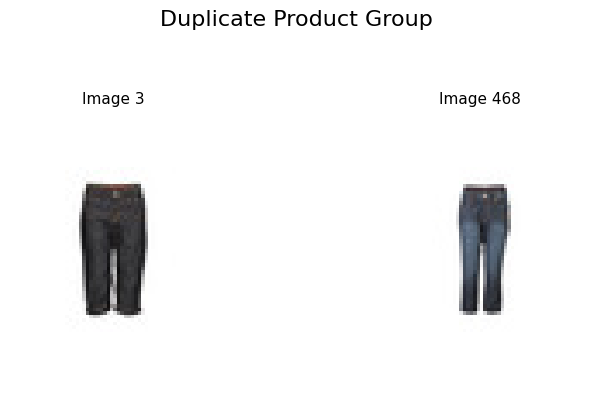

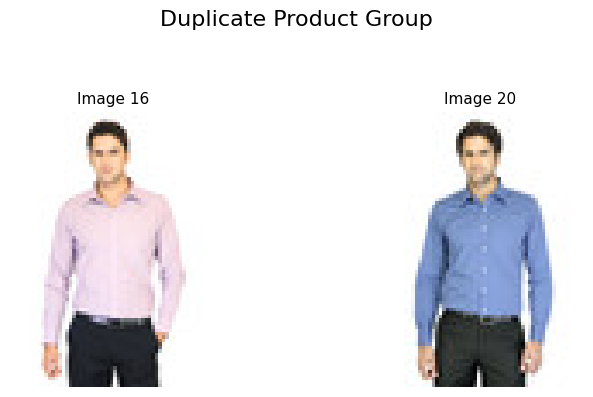

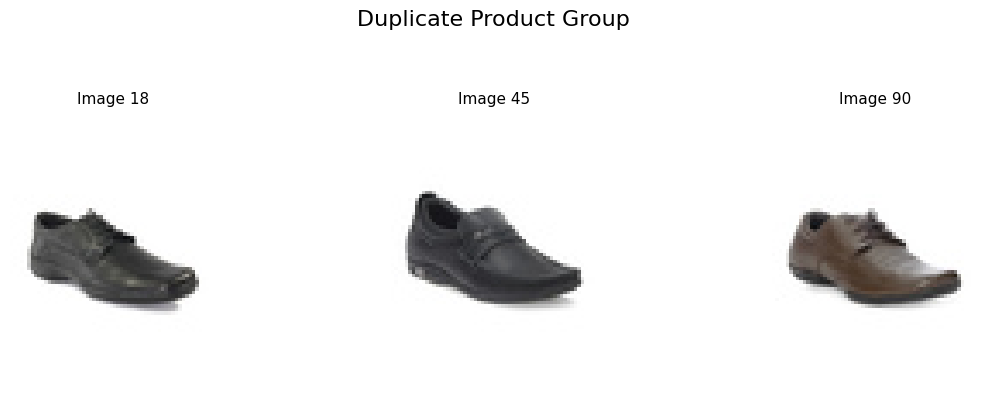

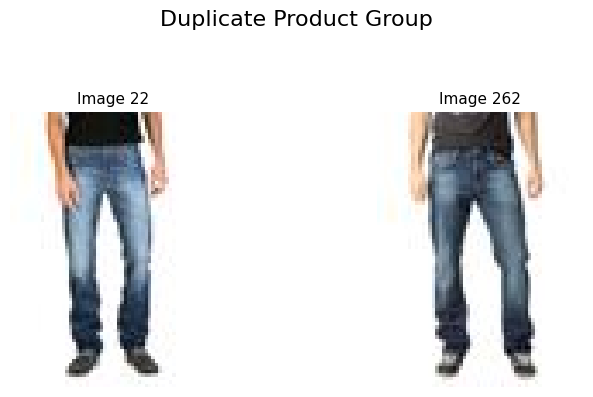

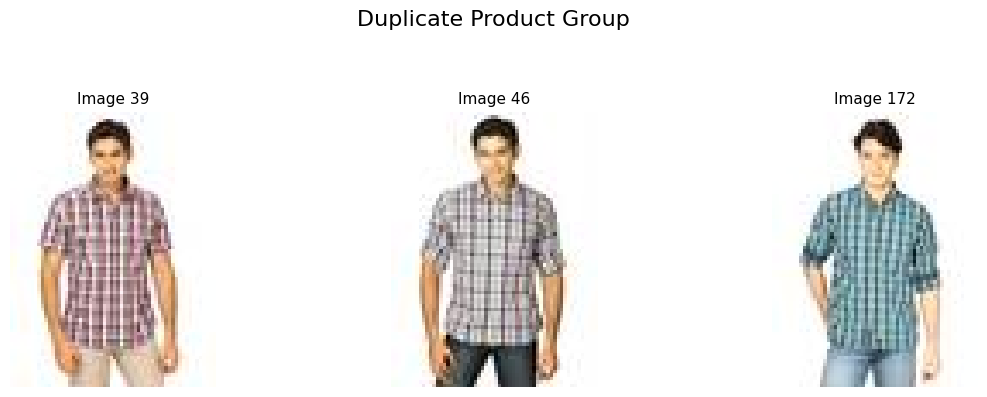

In [26]:
import matplotlib.pyplot as plt
from PIL import Image

count = 0

for group in duplicate_groups:

    if len(group) > 1:

        fig, axes = plt.subplots(1, len(group), figsize=(4*len(group), 4))

        # If only 2 images, axes is still iterable
        if len(group) == 2:
            axes = list(axes)

        for ax, idx in zip(axes, group):
            img = Image.open(image_files[idx])
            ax.imshow(img)
            ax.set_title(f"Image {idx}", fontsize=11)
            ax.axis("off")

        fig.suptitle("Duplicate Product Group", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.90])   # Leaves space for title
        plt.show()

        count += 1

        if count == 5:
            break

In [27]:
print("="*60)
print("         UNIQUE PRODUCT CATALOG")
print("="*60)

print(f"Original Products : {len(image_files)}")
print(f"Unique Products   : {len(unique_catalog)}")
print(f"Duplicates Removed: {len(image_files) - len(unique_catalog)}")

         UNIQUE PRODUCT CATALOG
Original Products : 500
Unique Products   : 455
Duplicates Removed: 45


In [28]:
import pandas as pd

catalog_df = pd.DataFrame({
    "Unique_Product": unique_catalog
})

catalog_df.to_csv("unique_product_catalog.csv", index=False)

print("✅ Unique Product Catalog saved as unique_product_catalog.csv")

✅ Unique Product Catalog saved as unique_product_catalog.csv
